# Nasdaq Black Swan - Modelare (6 Modele)
**Modele:** Naive Bayes, Logistic Regression, SVM RBF, Random Forest, LightGBM, Voting Ensemble  
**Date:** Agregare saptamanala Nasdaq, target binar V-shape (>8%) vs Non-V

## 1. Import si Incarcare Date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes        import GaussianNB
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve, f1_score
)
from matplotlib.patches import Patch
import lightgbm as lgb

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

train_df = pd.read_csv('nasdaq_train.csv', index_col=0, parse_dates=True)
test_df  = pd.read_csv('nasdaq_test.csv',  index_col=0, parse_dates=True)

with open('nasdaq_feature_cols.json') as f:
    feature_cols = json.load(f)

print('Train:', len(train_df), 'saptamani | Test:', len(test_df), 'saptamani')
print('Features:', len(feature_cols))
print(feature_cols)

Train: 412 saptamani | Test: 160 saptamani
Features: 14
['Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200', 'Dist_52w_High', 'Dist_Local_Min', 'VIX', 'VIX_Ratio', 'VIX_Trend_20d', 'Realized_Vol_10d', 'Volume_Ratio', 'RSI', 'SP500_Trend_20d', 'Phase']


## 2. Pregatire X / y si Scalare

In [2]:
X_train_raw = train_df[feature_cols]
y_train     = train_df['label']
X_test_raw  = test_df[feature_cols]
y_test      = test_df['label']

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

print('Scalare completata.')
print('Raport Non-V / V-shape:', round(ratio, 2))
print('Train - Non-V:', (y_train==0).sum(), '| V-shape:', (y_train==1).sum())
print('Test  - Non-V:', (y_test==0).sum(),  '| V-shape:', (y_test==1).sum())

Scalare completata.
Raport Non-V / V-shape: 2.12
Train - Non-V: 280 | V-shape: 132
Test  - Non-V: 112 | V-shape: 48


## 3. Definire Modele

In [3]:
base_models = {
    'Naive Bayes': GaussianNB(),

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'SVM RBF': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        is_unbalance=True,
        random_state=42,
        verbose=-1
    )
}

print('Modele definite:', list(base_models.keys()))

Modele definite: ['Naive Bayes', 'Logistic Regression', 'SVM RBF', 'Random Forest', 'LightGBM']


## 4. Antrenare si Evaluare

In [4]:
results = {}

for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'acc'    : acc,
        'auc'    : auc
    }
    print(name.ljust(22), 'Accuracy:', round(acc, 3), '| ROC AUC:', round(auc, 3))

# Voting Ensemble: top 3 dupa AUC
top3       = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:3]
top3_names = [n for n, _ in top3]
print('\nTop 3 pentru Voting Ensemble:', top3_names)

ensemble = VotingClassifier(
    estimators=[(n, results[n]['model']) for n in top3_names],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ens  = ensemble.predict(X_test)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]
acc_ens     = accuracy_score(y_test, y_pred_ens)
auc_ens     = roc_auc_score(y_test, y_proba_ens)

results['Voting Ensemble'] = {
    'model'  : ensemble,
    'y_pred' : y_pred_ens,
    'y_proba': y_proba_ens,
    'acc'    : acc_ens,
    'auc'    : auc_ens
}
print('Voting Ensemble'.ljust(22), 'Accuracy:', round(acc_ens, 3), '| ROC AUC:', round(auc_ens, 3))
print('\nAntrenare completa.')

Naive Bayes            Accuracy: 0.644 | ROC AUC: 0.616
Logistic Regression    Accuracy: 0.569 | ROC AUC: 0.58
SVM RBF                Accuracy: 0.656 | ROC AUC: 0.678
Random Forest          Accuracy: 0.706 | ROC AUC: 0.661
LightGBM               Accuracy: 0.656 | ROC AUC: 0.653

Top 3 pentru Voting Ensemble: ['SVM RBF', 'Random Forest', 'LightGBM']
Voting Ensemble        Accuracy: 0.713 | ROC AUC: 0.668

Antrenare completa.


## 5. Classification Report

In [5]:
separator = '=' * 50
for name, res in results.items():
    print(separator)
    print(name)
    print(separator)
    print(classification_report(y_test, res['y_pred'], target_names=['Non-V (0)', 'V-shape (1)']))
    print()

Naive Bayes
              precision    recall  f1-score   support

   Non-V (0)       0.76      0.71      0.74       112
 V-shape (1)       0.42      0.48      0.45        48

    accuracy                           0.64       160
   macro avg       0.59      0.60      0.59       160
weighted avg       0.66      0.64      0.65       160


Logistic Regression
              precision    recall  f1-score   support

   Non-V (0)       0.74      0.59      0.66       112
 V-shape (1)       0.35      0.52      0.42        48

    accuracy                           0.57       160
   macro avg       0.55      0.56      0.54       160
weighted avg       0.62      0.57      0.59       160


SVM RBF
              precision    recall  f1-score   support

   Non-V (0)       0.75      0.76      0.76       112
 V-shape (1)       0.43      0.42      0.42        48

    accuracy                           0.66       160
   macro avg       0.59      0.59      0.59       160
weighted avg       0.65      0.6

## 6. ROC Curves

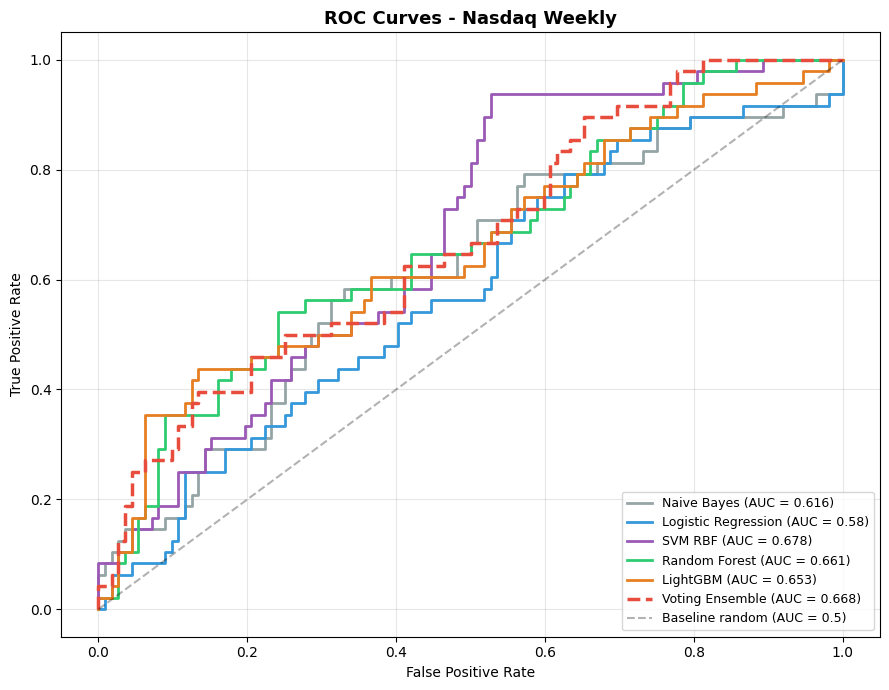

Salvat: plots/nasdaq_roc_curves.png


In [6]:
colors = ['#95a5a6', '#3498db', '#9b59b6', '#2ecc71', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    style = '--' if name == 'Voting Ensemble' else '-'
    lw    = 2.5  if name == 'Voting Ensemble' else 2
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=style,
            label=name + ' (AUC = ' + str(round(res['auc'], 3)) + ')')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Baseline random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Nasdaq Weekly', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/nasdaq_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_roc_curves.png')

## 7. Threshold Optimization

Model selectat: SVM RBF
Threshold optim: 0.14
F1 V-shape la threshold optim: 0.592


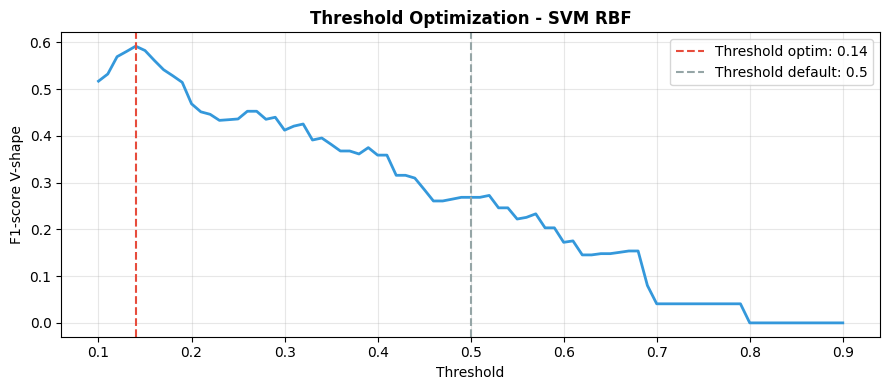

Salvat: plots/nasdaq_threshold_optimization.png


In [7]:
best_model_name = max(results, key=lambda n: results[n]['auc'])
best_proba      = results[best_model_name]['y_proba']
print('Model selectat:', best_model_name)

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int),
               pos_label=1, zero_division=0) for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1        = max(f1_scores)

print('Threshold optim:', round(optimal_threshold, 2))
print('F1 V-shape la threshold optim:', round(optimal_f1, 3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#3498db', linewidth=2)
ax.axvline(optimal_threshold, color='#e74c3c', linestyle='--',
           label='Threshold optim: ' + str(round(optimal_threshold, 2)))
ax.axvline(0.5, color='#95a5a6', linestyle='--', label='Threshold default: 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-score V-shape')
ax.set_title('Threshold Optimization - ' + best_model_name, fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/nasdaq_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_threshold_optimization.png')

## 8. Confusion Matrices

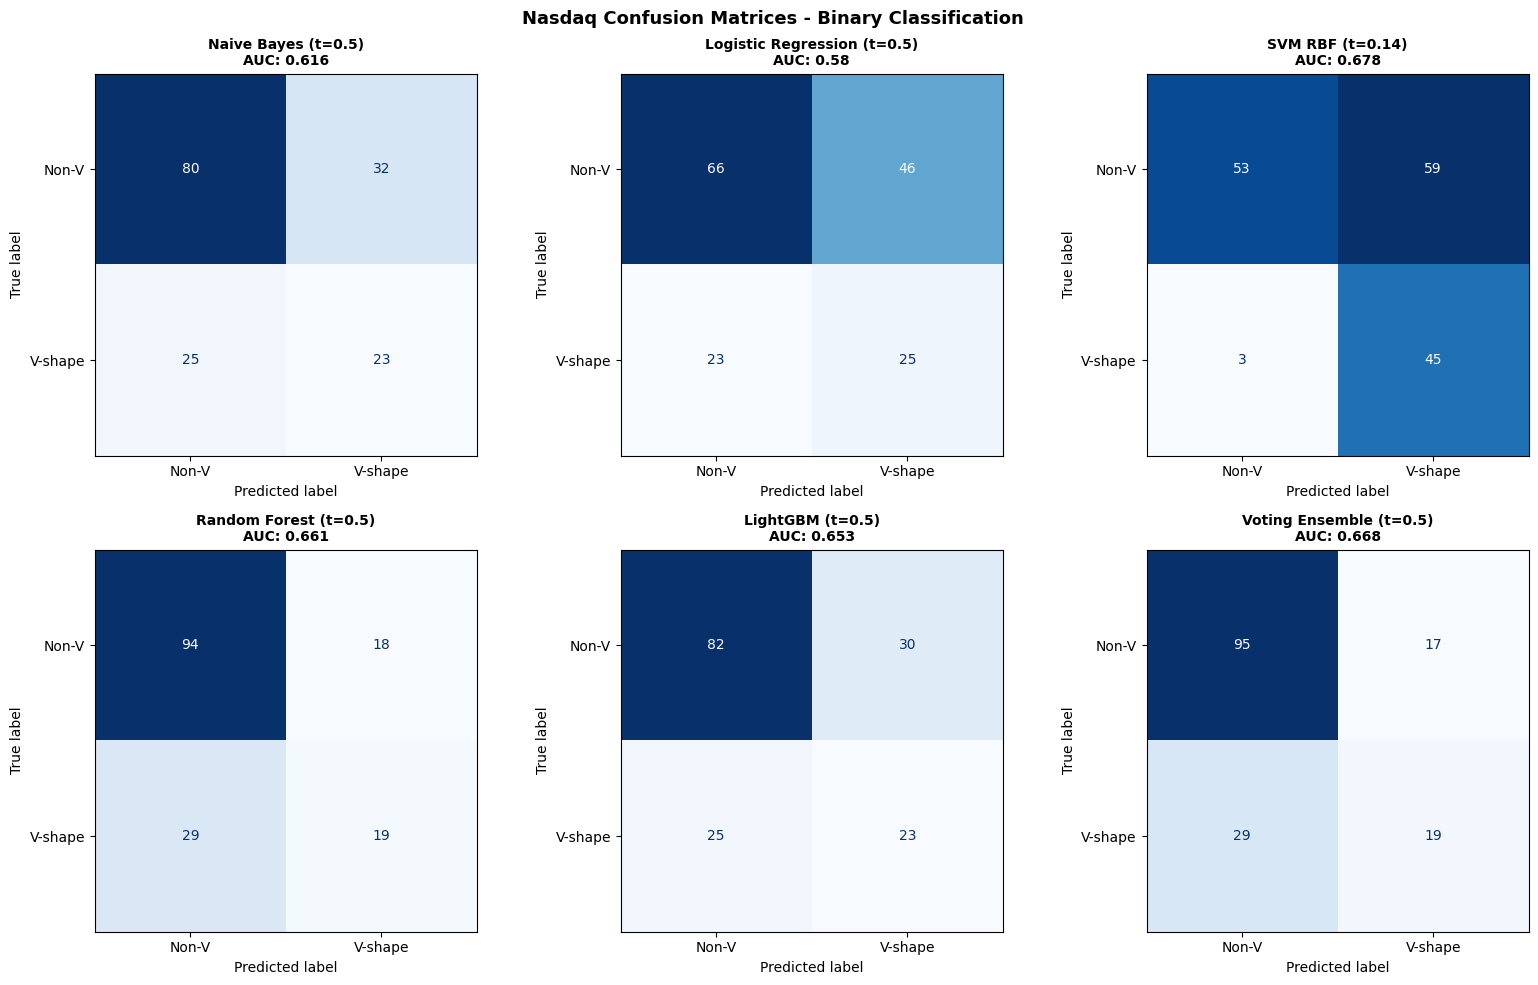

Salvat: plots/nasdaq_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    if name == best_model_name:
        y_pred_plot  = (res['y_proba'] >= optimal_threshold).astype(int)
        title_suffix = ' (t=' + str(round(optimal_threshold, 2)) + ')'
    else:
        y_pred_plot  = res['y_pred']
        title_suffix = ' (t=0.5)'

    cm   = confusion_matrix(y_test, y_pred_plot)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-V', 'V-shape'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        name + title_suffix + '\nAUC: ' + str(round(res['auc'], 3)),
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Nasdaq Confusion Matrices - Binary Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/nasdaq_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_confusion_matrices.png')

## 9. Feature Importance

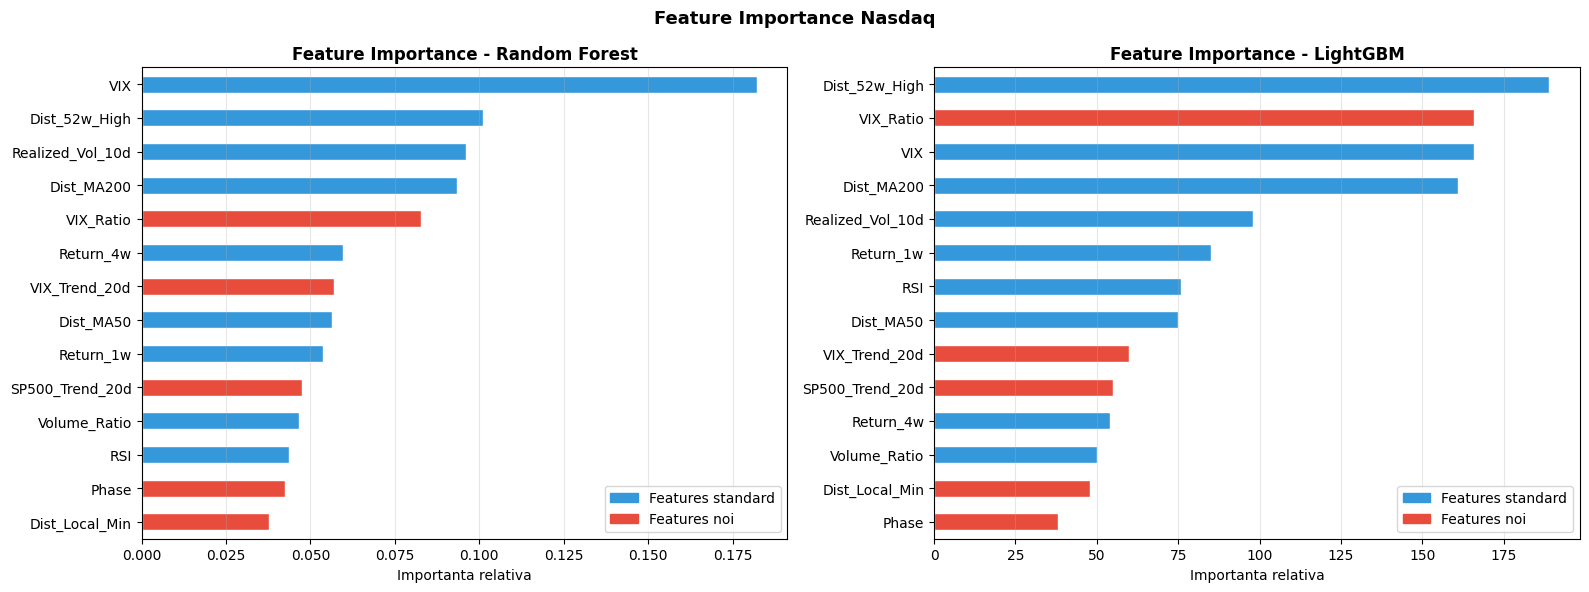

Salvat: plots/nasdaq_feature_importance.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
new_features = ['VIX_Trend_20d', 'SP500_Trend_20d', 'Dist_Local_Min', 'VIX_Ratio', 'Phase']

for ax, model_name in zip(axes, ['Random Forest', 'LightGBM']):
    importances = pd.Series(
        results[model_name]['model'].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)

    bar_colors = ['#e74c3c' if f in new_features else '#3498db' for f in importances.index]
    importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title('Feature Importance - ' + model_name, fontweight='bold')
    ax.set_xlabel('Importanta relativa')
    ax.grid(True, axis='x', alpha=0.3)
    legend = [Patch(color='#3498db', label='Features standard'),
              Patch(color='#e74c3c', label='Features noi')]
    ax.legend(handles=legend, loc='lower right')

plt.suptitle('Feature Importance Nasdaq', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/nasdaq_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_feature_importance.png')

## 10. Probabilitati per Eveniment de Test

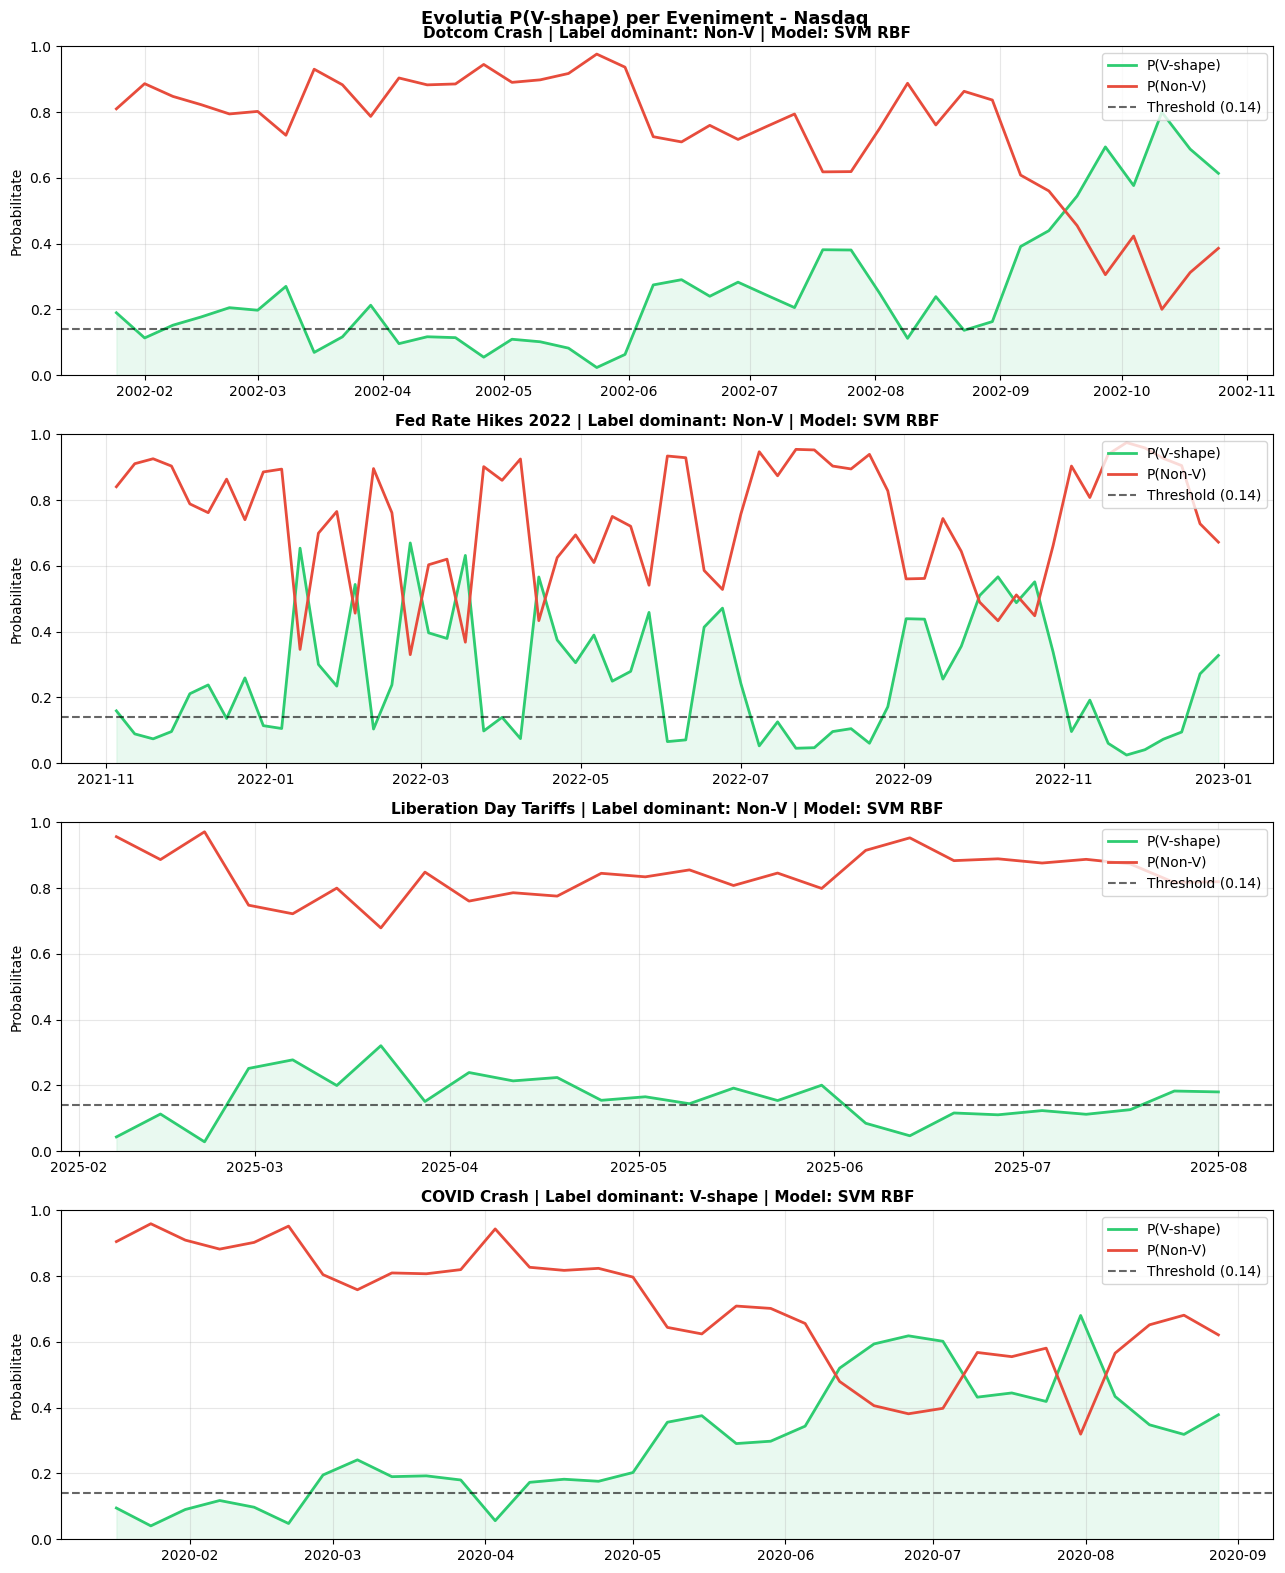

Salvat: plots/nasdaq_probabilities_per_event.png


In [10]:
best_model = results[best_model_name]['model']
best_proba = results[best_model_name]['y_proba']

proba_df = pd.DataFrame({
    'P_VShape'   : best_proba,
    'P_NonV'     : 1 - best_proba,
    'event_name' : test_df['event_name'].values,
    'true_label' : test_df['label'].values
}, index=test_df.index)

test_event_names = test_df['event_name'].unique()
fig, axes = plt.subplots(len(test_event_names), 1, figsize=(13, 4 * len(test_event_names)))
if len(test_event_names) == 1:
    axes = [axes]

for ax, event in zip(axes, test_event_names):
    ev      = proba_df[proba_df['event_name'] == event]
    dom_lbl = 'V-shape' if ev['true_label'].mode()[0] == 1 else 'Non-V'

    ax.plot(ev.index, ev['P_VShape'], color='#2ecc71', linewidth=2, label='P(V-shape)')
    ax.plot(ev.index, ev['P_NonV'],   color='#e74c3c', linewidth=2, label='P(Non-V)')
    ax.axhline(optimal_threshold, color='black', linestyle='--', alpha=0.6,
               label='Threshold (' + str(round(optimal_threshold, 2)) + ')')
    ax.fill_between(ev.index, ev['P_VShape'], alpha=0.1, color='#2ecc71')
    ax.set_title(
        event + ' | Label dominant: ' + dom_lbl + ' | Model: ' + best_model_name,
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Probabilitate')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolutia P(V-shape) per Eveniment - Nasdaq', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/nasdaq_probabilities_per_event.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_probabilities_per_event.png')

## 11. Salvare Model

In [12]:
pickle.dump(results[best_model_name]['model'], open('models/nasdaq_best_model.pkl', 'wb'))
pickle.dump(scaler,                            open('models/nasdaq_scaler.pkl',     'wb'))
pickle.dump(ensemble,                          open('models/nasdaq_ensemble.pkl',   'wb'))

meta = {
    'model_name'        : best_model_name,
    'auc'               : round(results[best_model_name]['auc'], 4),
    'accuracy'          : round(results[best_model_name]['acc'], 4),
    'optimal_threshold' : round(float(optimal_threshold), 2),
    'feature_cols'      : feature_cols,
    'ticker'            : '^IXIC',
    'v_threshold'       : 0.08,
    'forward_days'      : 60,
    'frequency'         : 'weekly',
    'top3_ensemble'     : top3_names,
    'classes'           : {0: 'Non-V', 1: 'V-shape'}
}
with open('models/nasdaq_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Fisiere salvate in models/:')
print('  nasdaq_best_model.pkl')
print('  nasdaq_scaler.pkl')
print('  nasdaq_ensemble.pkl')
print('  nasdaq_model_meta.json')

Fisiere salvate in models/:
  nasdaq_best_model.pkl
  nasdaq_scaler.pkl
  nasdaq_ensemble.pkl
  nasdaq_model_meta.json


## 12. Rezumat Final + Comparatie cu SP500

In [11]:
separator = '=' * 55
print('REZUMAT NASDAQ')
print(separator)

summary = pd.DataFrame([
    {'Model': n, 'Accuracy': round(r['acc'], 3), 'AUC': round(r['auc'], 3)}
    for n, r in results.items()
]).sort_values('AUC', ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.to_string())

print('\nSP500 V4 best AUC (LightGBM):        0.764')
print('SP500 V4 Ensemble AUC:               0.751')
print('Nasdaq best AUC (' + best_model_name + '):', round(results[best_model_name]['auc'], 3))
print('Nasdaq Ensemble AUC:', round(results['Voting Ensemble']['auc'], 3))
print('\nThreshold optim Nasdaq:', round(float(optimal_threshold), 2))
print('\nGata pentru nasdaq_dashboard.ipynb')

REZUMAT NASDAQ
                 Model  Accuracy    AUC
1              SVM RBF     0.656  0.678
2      Voting Ensemble     0.713  0.668
3        Random Forest     0.706  0.661
4             LightGBM     0.656  0.653
5          Naive Bayes     0.644  0.616
6  Logistic Regression     0.569  0.580

SP500 V4 best AUC (LightGBM):        0.764
SP500 V4 Ensemble AUC:               0.751
Nasdaq best AUC (SVM RBF): 0.678
Nasdaq Ensemble AUC: 0.668

Threshold optim Nasdaq: 0.14

Gata pentru nasdaq_dashboard.ipynb
